In [2]:
from rtrv_models.cscg import CSCG
from rtrv_models.data.graph import MazeEnv, maze1_graph, check_relation, CP_DSP1, maze2_graph, get_metric
from rtrv_models.data.preprocess import PreprocessedData, preprocess_data
import numpy as np
from rtrv_models.data._io import load_data, SAVE_DIR
import pandas as pd
import os
import pickle

DSPPalette = ["#A9CCE3", "#82C3C5", '#9C8FBC', "#D9A6A9", "#DCC8A4", '#647D91', "#C06C84"]

maze1 = MazeEnv(maze1_graph)
obs_counts1 = np.histogram(maze1.obs, range=(-0.5, 5.5), bins=6)
print(obs_counts1)
maze2 = MazeEnv(maze2_graph)
obs_counts2 = np.histogram(maze2.obs, range=(-0.5, 5.5), bins=6)
print(obs_counts2)

n_clones = (np.mean(np.vstack([obs_counts1[0], obs_counts2[0]]), axis=0) * 6).astype(np.int64)
print(n_clones)


for mouse in [10212, 10224, 10227, 10232]:
    print(f"Processing mouse {mouse}")
    if os.path.exists(os.path.join(SAVE_DIR, f"cscg_{mouse}.pkl")):
        print("  Existed, skip.")
        continue

    res: PreprocessedData = preprocess_data(mouse)
    x = res.obs_train
    a = res.all_act_train
    beg_train, end_train = res.get_lap_dur_train()
    is_maze1 = res.maze_train[beg_train] == 1

    n_obs = 6
    pseudocount = 1e-5
    n_iters = 100

    cscg = CSCG(n_clones=n_clones, act=a, obs=x, pseudocount=pseudocount)  # Initialize the model
    cscg.fit_by_trial(trial_beg=beg_train[is_maze1], trial_end=end_train[is_maze1], n_iter=n_iters)
    with open(os.path.join(SAVE_DIR, f"cscg_{mouse}.pkl"), "wb") as f:
        pickle.dump(cscg, f)
        
    x_ego = res.obs_train
    a_ego = res.ego_act_train
    
    cscg_ego = CSCG(n_clones=n_clones, act=a_ego, obs=x_ego, pseudocount=pseudocount)
    cscg_ego.fit_by_trial(trial_beg=beg_train, trial_end=end_train, n_iter=n_iters)
    with open(os.path.join(SAVE_DIR, f"cscg_{mouse}_ego.pkl"), "wb") as f:
        pickle.dump(cscg_ego, f)

(array([ 1, 17, 35, 74, 16,  1]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]))
(array([ 1, 19, 34, 71, 18,  1]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]))
[  6 108 207 435 102   6]
Processing mouse 10212
  Existed, skip.
Processing mouse 10224
  Existed, skip.
Processing mouse 10227
  Existed, skip.
Processing mouse 10232
  Existed, skip.


# Test Retrieval W/O Plasticity

775it [00:01, 580.07it/s]


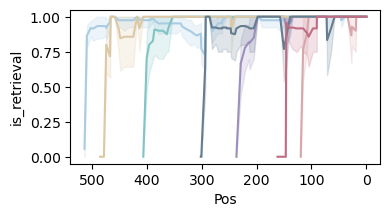

[[  0.  nan  nan ...  nan  nan  nan]
 [  1.  nan  nan ...  nan  nan  nan]
 [  2.  nan  nan ...  nan  nan  nan]
 ...
 [ nan  nan  nan ...  nan  nan  nan]
 [ nan  nan  nan ...  nan  nan  nan]
 [ nan  nan  nan ...  nan  nan 858.]]


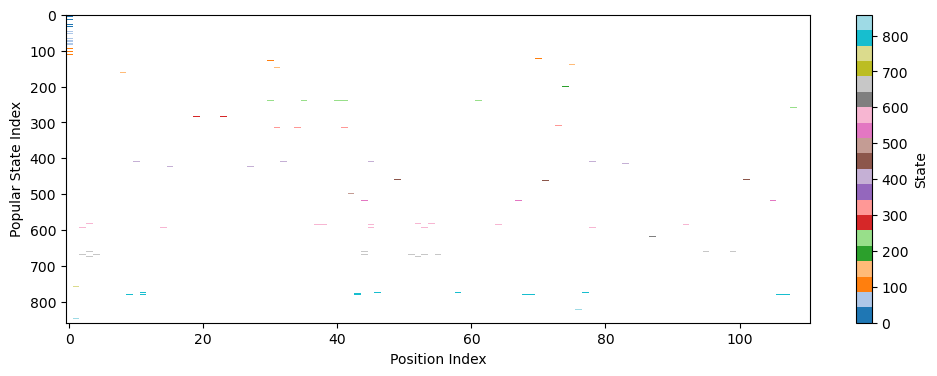

775it [00:01, 552.37it/s]


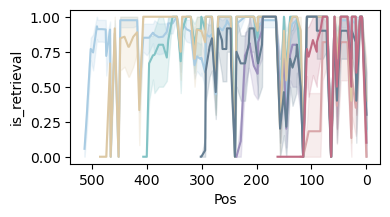

[[  0.  nan  nan ...  nan  nan  nan]
 [  1.  nan  nan ...  nan  nan  nan]
 [  2.  nan  nan ...  nan  nan  nan]
 ...
 [ nan  nan  nan ...  nan  nan 861.]
 [ nan  nan  nan ...  nan  nan 862.]
 [ nan  nan  nan ...  nan  nan 863.]]


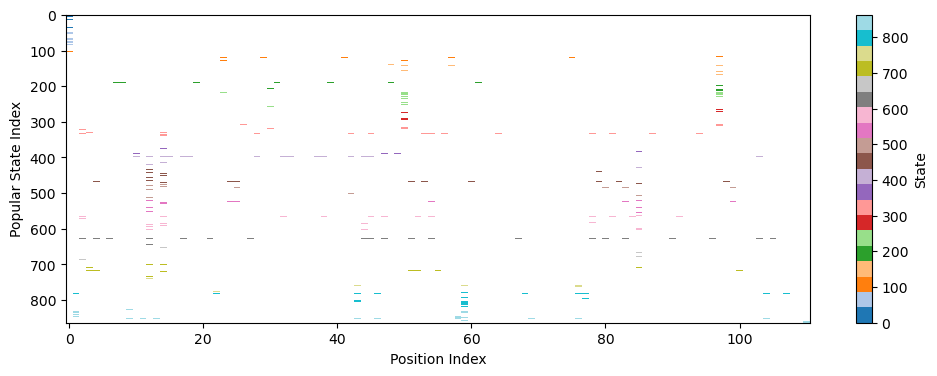

{'is_retrieval': array([0., 0., 1., ..., 1., 1., 0.], shape=(8952,)),
 'Pos': array([513.82485678, 509.50340468, 502.51114828, ...,  11.3137085 ,
          8.        ,   0.        ], shape=(8952,)),
 'Route': array([0., 0., 0., ..., 0., 0., 0.], shape=(8952,))}

In [5]:
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from tqdm import tqdm

def visualize_retrieval(mouse, model: str = 'all'):
    """
    Visualize the retrieval performance of a CSCG model for a given mouse.
    
    Parameters
    ----------
    mouse : int
        The ID of the mouse to visualize.
    model : str, optional
        The model type to use, by default 'all' but can be set to 'ego' to use 
        the ego-centric model.
    """
    
    if model == 'all':
        model_file = f"cscg_{mouse}.pkl"
    elif model == 'ego':
        model_file = f"cscg_{mouse}_ego.pkl"
    else:
        raise ValueError(f"Unknown model type: {model}")
        
    D1 = get_metric(1)
    with open(os.path.join(SAVE_DIR, model_file), 'rb') as f:
        chmm: CSCG = pickle.load(f)

    res: PreprocessedData = preprocess_data(mouse)

    if model == 'all':
        x_test = res.obs_test
        a_test = res.all_act_test
    elif model == 'ego':
        x_test = res.obs_test
        a_test = res.ego_act_test

    p_test = res.pos_test
    r_test = res.route_test
    s_test = res.session_test

    a_perf, x_perf = res.get_ideal_seq(rt=0, mode=model)
    state_perf = np.zeros(144)
    state_perf[CP_DSP1[0]-1] = chmm.predict(x_perf, a_perf)

    beg, end = res.get_lap_dur_test()
    is_retrieval = np.zeros(len(x_test))
    state_pred = np.zeros(len(x_test), np.int32)
    for b, e in tqdm(zip(beg, end)):
        if s_test[b] != 0:
            continue

        state_pred[b:e] = chmm.model.decode(x_test[b:e], a_test[b:e])[1]
        state_test = state_perf[p_test[b:e]-1]
        is_retrieval[b:e] = np.where(state_test-state_pred[b:e]==0, 1, 0)
        
    x = D1[p_test-1, 143]
    idx = np.where(
        (np.isin(p_test, CP_DSP1[0])&(s_test==0)) | 
        (np.isin(p_test, CP_DSP1[4])&(r_test==4)&(s_test==0)) | 
        (np.isin(p_test, CP_DSP1[5])&(r_test==5)&(s_test==0)) | 
        (np.isin(p_test, CP_DSP1[6])&(r_test==6)&(s_test==0))
    )[0]

    data = {
        "is_retrieval": is_retrieval[idx],
        "Pos": x[idx],
        "Route": r_test[idx],
    }
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes()
    sns.lineplot(
        x="Pos", 
        y="is_retrieval", 
        hue="Route", 
        palette=DSPPalette, 
        data=data, ax=ax,
        legend=False
    )
    ax.invert_xaxis()
    plt.show()
    
    
    popular_state = []
    for i, b in enumerate(CP_DSP1[0]):
        res_idx = np.where((data['Route'] == 0)&(p_test[idx] == b)&(s_test[idx] == 0))[0]
        if len(res_idx) == 0:
            popular_state.append(np.array([]))
        else:
            popular_state.append(np.unique(state_pred[idx[res_idx]]))
        
    imax = np.max(state_pred)+1
    popular_state_ = np.zeros((imax, len(popular_state)), np.int32)*np.nan
    for i, s in enumerate(popular_state):
        popular_state_[s, i] = s
    
    plt.figure(figsize=(12, 4))
    plt.imshow(popular_state_, aspect='auto', cmap='tab20', interpolation='none')
    print(popular_state_)
    plt.colorbar(label='State')
    plt.xlabel('Position Index')
    plt.ylabel('Popular State Index')
    plt.show()
    
    return data

visualize_retrieval(10232)
visualize_retrieval(10232, model='ego')